In [107]:
## The goal of this notebook is to study the applicability of private (non-)membership proof delegation
## in a stateless blockchain application. The empirical data is taken from here: https://insights.glassnode.com/time-is-money-how-coin-age-shapes-bitcoins-spending-patterns/

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.colors import LogNorm
import matplotlib.colors as colors

In [180]:
## Transaction per second that we want to simulate
## We roughly both want to capture Bitcoin (7 tps), Ethereum's throguhput with L2s (100 tps roughly) and VISA/Mastercard (10k tps)
tps = [2**i for i in range(1,9)]
## Offline-time interval length (this is the offline period length that we can support)
server_time = [2**i for i in range(1,28,4)] ## in hours (the PSN server is running for this many hours to do its job)

In [181]:
## Bitcoin's empirical coin age follows a power-law distribution
## See the data and measurements here: https://insights.glassnode.com/time-is-money-how-coin-age-shapes-bitcoins-spending-patterns/
## This power-law distribution can be approximated with the following line on a log-log scale
intercept = -1.4159
slope = -0.9550
## To ease calculations let's just compute with the average of this distribution
average_coin_age_days = 162 ## in days (this is a rough estimation given the empirical data above)
## median_coin_age_days = 40 //average 162
average_coin_age_hours = average_coin_age_days*24
average_coin_age_seconds = average_coin_age_hours*60*60 ## in seconds
miliSecondsInHour = 3600000
hoursInMonth = 731

In [182]:
tx3_large_cost_per_hour = 0.208  # in USD, from https://calculator.aws/#/createCalculator/ec2-enhancement on 2026-04-09

In [183]:
bilinear_running_times = [1.593770, 3.538859, 9.606699,	26.058632,	65.352250,	131.966387,	274.302579,	790.240733] ## in miliseconds
y = [math.log2(i) for i in bilinear_running_times]
x = [i+3 for i in range(len(y))]
print(x)
print(y)
## Linear regression results on the data above (R^2=0.9990)
intercept_runtimes = -2.4808
slope_runtimes = 1.0367

[3, 4, 5, 6, 7, 8, 9, 10]
[0.6724434462662564, 1.8232842811038672, 3.2640407853757254, 4.703689443619993, 6.0301650020322075, 7.044026699027231, 8.099624376281072, 9.626148401798412]


In [184]:
print(tps)

[2, 4, 8, 16, 32, 64, 128, 256]


In [185]:
## Bilinear membership proof-delegation
noOfThreads = 8 ## number of threads at the AWS server machine
crs_length = 2**28 ## currently, this is the largest Powers-of-tau trusted setup that one could use in an application without relying on an entirely new trusted setup ceremony
bilinear_upd_cost = np.zeros((len(tps),len(server_time)))
for i in range(0,len(tps)):
    for j in range(0,len(server_time)):
        ## for each coin, there were this many new coins added to the UTXO set meanwhile it had not been spent
        necessaryUpdatesPerCoin = average_coin_age_seconds*tps[i]
        if necessaryUpdatesPerCoin<crs_length: ##otherwise, it would not even be possible to do the membership proof update  
            updates_per_threads = (tps[i]*(slope_runtimes*(math.log2(necessaryUpdatesPerCoin))+intercept_runtimes))/noOfThreads
            ## the runtime above were given in miliseconds, thus we need to convert them to hour
            upd_cost_per_hour = updates_per_threads/miliSecondsInHour ## the workload can be done in parallel
            bilinear_upd_cost[i,j]=(upd_cost_per_hour*tx3_large_cost_per_hour*server_time[j]) ## let's assume the server is running for 1 year=12 months
bilinear_upd_cost

array([[6.69231336e-07, 1.07077014e-05, 1.71323222e-04, 2.74117155e-03,
        4.38587448e-02, 7.01739917e-01, 1.12278387e+01],
       [1.39836089e-06, 2.23737743e-05, 3.57980389e-04, 5.72768622e-03,
        9.16429795e-02, 1.46628767e+00, 2.34606028e+01],
       [2.91651823e-06, 4.66642917e-05, 7.46628667e-04, 1.19460587e-02,
        1.91136939e-01, 3.05819102e+00, 4.89310563e+01],
       [6.07262935e-06, 9.71620696e-05, 1.55459311e-03, 2.48734898e-02,
        3.97975837e-01, 6.36761340e+00, 1.01881814e+02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0

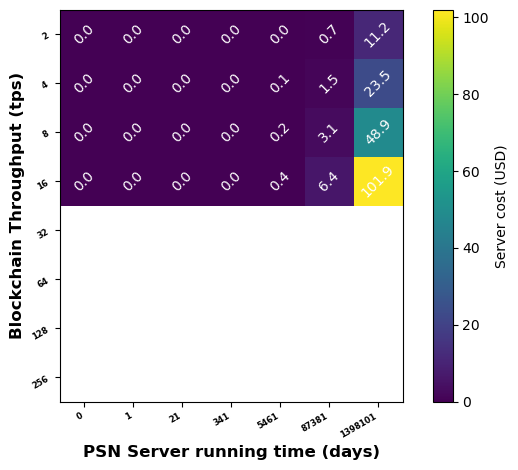

In [189]:
fig, ax = plt.subplots()

cmap = plt.cm.viridis.copy()
cmap.set_under('white')

im = ax.imshow(bilinear_upd_cost, cmap=cmap,vmin=1e-9, vmax=bilinear_upd_cost.max())
plt.ylabel('Blockchain Throughput (tps)', fontweight='bold', color = 'black', fontsize='12', horizontalalignment='center')
plt.yticks(range(0,len(tps)), tps, color='black', rotation=30, fontweight='bold', fontsize='6', horizontalalignment='right')
plt.xlabel('PSN Server running time (days)', fontweight='bold', color = 'black', fontsize='12', horizontalalignment='center')
plt.xticks(range(0,len(server_time)), [round(i/24) for i in server_time], rotation=30, color='black', fontweight='bold', fontsize='6', horizontalalignment='right')

# Loop over data dimensions and create text annotations.
for i in range(len(tps)):
    for j in range(len(server_time)):
        text = ax.text(j, i, round(bilinear_upd_cost[i, j],1),
                       ha="center", va="center", color="w",rotation=45)

cbar = plt.colorbar(im,label="Server cost (USD)")
cbar.ax.tick_params(labelsize=10) 
fig.tight_layout()
plt.savefig("./images/case_study_bilinear.pdf")
plt.show()

In [188]:
## RSA membership proof-delegation